# 06 — Sparse Autoencoders (SAE) — Contribution C1

Mechanistic interpretability of **DeiT-Base** and **DINOv2-ViT-B/14**
on the CRC-VAL-HE-7K histology dataset (9 classes).

## Pipeline

```
Trained ViT
  → Collect MLP activations (blocks.8.mlp)
  → Train TopK-SAE (Gao et al., 2024)
  → Analyse features: top-K activating images per feature
  → Steerability: ablate/amplify features, measure class-probability shift
  → Save results + upload to Drive
```

**References**
- Cunningham et al. ICLR 2024 — "SAEs Find Highly Interpretable Features"
- Templeton et al. 2024 — "Scaling Monosemanticity" (Anthropic)
- Gao et al. 2024 — "Scaling and Evaluating SAEs" (OpenAI; TopK)

**Edit only** `USER CONFIG` to switch between models.

**Environment**: Kaggle GPU T4 / P100 — Phase 1 only.

In [7]:
import os
def upload_folder_recursive(local_folder_path, drive_folder_id):
    for item in os.listdir(local_folder_path):
        local_path = os.path.join(local_folder_path, item)

        if os.path.isdir(local_path):
            # Create subfolder in Drive
            subfolder_id = create_drive_folder(item, parent_id=drive_folder_id)
            print(f"Created folder in Drive: {item}")

            # Recurse
            upload_folder_recursive(local_path, subfolder_id)
        else:
            # Upload file
            file_drive = drive.CreateFile({
                'title': item,
                'parents': [{'id': drive_folder_id}]
            })
            file_drive.SetContentFile(local_path)
            file_drive.Upload()
            print("Uploaded file:", item)

upload_folder_recursive("/kaggle/working/xai-vit-medical/", folder_id)

Created folder in Drive: src
Created folder in Drive: xai
Created folder in Drive: classical
Uploaded file: generic_attention.py
Uploaded file: attention_rollout.py
Uploaded file: integrated_gradients.py
Uploaded file: gradcam.py
Uploaded file: lrp.py
Uploaded file: __init__.py
Created folder in Drive: mechanistic
Uploaded file: activation_patching.py
Uploaded file: sae.py
Uploaded file: circuit_discovery.py
Uploaded file: __init__.py
Uploaded file: __init__.py
Created folder in Drive: models
Uploaded file: dinov2.py
Uploaded file: factory.py
Uploaded file: __init__.py
Created folder in Drive: evaluation
Uploaded file: insertion_deletion.py
Uploaded file: sanity_checks.py
Uploaded file: run_xai.py
Uploaded file: clinical_validation.py
Uploaded file: __init__.py
Created folder in Drive: training
Uploaded file: trainer.py
Uploaded file: __init__.py
Created folder in Drive: utils
Uploaded file: seed.py
Uploaded file: logger.py
Uploaded file: __init__.py
Created folder in Drive: data
Uploa

In [1]:
# 0. Kaggle setup
!rm -rf /kaggle/working/xai-vit-medical
!git clone https://github.com/youssef-nouiouar/xai-vit-medical.git /kaggle/working/xai-vit-medical
!pip install -q timm albumentations loguru
!pip install -q PyDrive2
!pip install -q scikit-learn

Cloning into '/kaggle/working/xai-vit-medical'...
remote: Enumerating objects: 272, done.
remote: Counting objects: 100% (272/272), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 272 (delta 139), reused 204 (delta 81), pack-reused 0 (from 0)
Receiving objects: 100% (272/272), 1.36 MiB | 16.73 MiB/s, done.
Resolving deltas: 100% (139/139), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.1 MB/s eta 0:00:00


In [32]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [8]:
# ============================================================
# USER CONFIG — edit this cell only
# ============================================================

# Primary SAE targets: deit_base | dinov2
MODEL_NAME = "deit_base"

# Google Drive folder containing the checkpoint
DRIVE_FOLDER_ID = "1eq-Jt6O6gO0Ck_oQYwmmc2qrCVLfKlec"  # <-- update as needed

# ── Activation collection ──
MAX_BATCHES_COLLECT = 100    # batches from train split (batch_size × MAX_BATCHES_COLLECT images)
COLLECT_BATCH_SIZE  = 32     # images per batch during collection
TOKEN_SELECTION     = "patch" # "patch" | "cls" | "all"

# ── SAE architecture ──
# Production: d_sae=12288 (16× expansion). Use 4096 for fast Kaggle runs.
D_SAE       = 4096           # hidden dimension (feature count)
K_SPARSE    = 40             # active features per token

# ── SAE training ──
TRAIN_BATCH_SIZE = 4096
NUM_EPOCHS       = 10
LEARNING_RATE    = 5e-5
WARMUP_STEPS     = 500

# ── Feature analysis ──
TOP_K_IMAGES_PER_FEATURE = 16   # top activating images to keep per feature
N_FEATURES_VISUALIZE     = 32   # features to show in montage

# ── Steerability ──
N_STEER_IMAGES   = 50
STEER_BATCH_SIZE = 8

# ── General ──
IMAGE_SIZE  = 224
NUM_WORKERS = 2
SEED        = 42
CACHE_ACTS  = True    # cache activations to disk; set False to recompute

# Paths (Kaggle)
TRAINVAL_ROOT_STR = "/kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/NCT-CRC-HE-100K/NCT-CRC-HE-100K"
TEST_ROOT_STR     = "/kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/CRC-VAL-HE-7K/CRC-VAL-HE-7K"
PROJECT_ROOT      = "/kaggle/working/xai-vit-medical"

In [14]:
# ============================================================
# Per-model SAE configuration
# ============================================================

SAE_MODEL_CONFIGS = {
    "deit_base": {
        "source"           : "timm",
        "timm_name"        : "deit_base_patch16_224",
        "checkpoint_fname" : "deit_base_best.pth",
        "target_layer"     : "blocks.8.mlp",     # MLP output at block 8
        "d_in"             : 768,
        "num_extra_tokens" : 1,   # CLS +(DIST)  i forget the dist i use only the standard deit
        "n_patch_tokens"   : 196, # 14×14
    },
    "dinov2": {
        "source"           : "torch_hub",
        "timm_name"        : None,
        "checkpoint_fname" : "dinov2_best.pth",
        "target_layer"     : "backbone.blocks.8.mlp",
        "d_in"             : 768,
        "num_extra_tokens" : 1,   # CLS only
        "n_patch_tokens"   : 256, # 16×16
    },
}

assert MODEL_NAME in SAE_MODEL_CONFIGS, (
    f"Unknown MODEL_NAME: {MODEL_NAME}. Choose from {list(SAE_MODEL_CONFIGS)}"
)
MCFG = SAE_MODEL_CONFIGS[MODEL_NAME]
D_IN          = MCFG["d_in"]
TARGET_LAYER  = MCFG["target_layer"]

print(f"Model         : {MODEL_NAME}")
print(f"Target layer  : {TARGET_LAYER}")
print(f"d_in          : {D_IN}")
print(f"d_sae         : {D_SAE}  (expansion ×{D_SAE/D_IN:.1f})")
print(f"k             : {K_SPARSE}")
print(f"Token selection: {TOKEN_SELECTION} ({MCFG['n_patch_tokens']} patch tokens/image)")

Model         : deit_base
Target layer  : blocks.8.mlp
d_in          : 768
d_sae         : 4096  (expansion ×5.3)
k             : 40
Token selection: patch (196 patch tokens/image)


In [12]:
import csv
import gc
import json
import os
import sys
from collections import defaultdict
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from PIL import Image
from torch.utils.data import DataLoader, Subset
from tqdm.notebook import tqdm

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.data.crc_dataset import CRCHistologyDataset, CRCSplits, DEFAULT_CRC_CLASSES
from src.utils.seed import set_seed
from src.xai.mechanistic.sae import (
    TopKSAE,
    collect_activations,
    train_sae,
    analyze_features,
)

set_seed(SEED)
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = list(DEFAULT_CRC_CLASSES)
NUM_CLASSES = len(CLASS_NAMES)

SAVE_DIR  = Path(f"{PROJECT_ROOT}/outputs/sae/{MODEL_NAME}")
CACHE_DIR = Path(f"{PROJECT_ROOT}/outputs/cache/{MODEL_NAME}")
for d in (SAVE_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

TRAINVAL_ROOT = Path(TRAINVAL_ROOT_STR)
TEST_ROOT     = Path(TEST_ROOT_STR)
CKPT_LOCAL="/kaggle/input/models/youssefnouiouar1/crt-deit/pytorch/default/1/deit_base_patch16_best.pth"

print(f"the path of the checkpoit :{CKPT_LOCAL}")
print(f"Device  : {DEVICE}")
print(f"Classes : {CLASS_NAMES}")
print(f"Output  : {SAVE_DIR}")

the path of the checkpoit :/kaggle/input/models/youssefnouiouar1/crt-deit/pytorch/default/1/deit_base_patch16_best.pth
Device  : cpu
Classes : ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
Output  : /kaggle/working/xai-vit-medical/outputs/sae/deit_base


In [15]:
# ── Build model ────────────────────────────────────────────────────────────

def load_state(model: nn.Module, ckpt_path: Path) -> dict:
    state = torch.load(ckpt_path, map_location="cpu")
    if "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
        return {k: v for k, v in state.items() if k != "model_state_dict"}
    if "state_dict" in state:
        cleaned = {k.replace("module.", "", 1): v for k, v in state["state_dict"].items()}
        model.load_state_dict(cleaned, strict=False)
        return {}
    cleaned = {k.replace("module.", "", 1): v for k, v in state.items()}
    model.load_state_dict(cleaned, strict=False)
    return {}


if MCFG["source"] == "torch_hub":
    from src.models.dinov2 import DINOv2Classifier
    model = DINOv2Classifier(num_classes=NUM_CLASSES, usage_mode="frozen_linear_probe")
else:
    model = timm.create_model(MCFG["timm_name"], pretrained=False, num_classes=NUM_CLASSES)

meta = load_state(model, CKPT_LOCAL)
model = model.to(DEVICE).eval()

print(f"Model            : {MODEL_NAME}")
print(f"Parameters       : {sum(p.numel() for p in model.parameters()):,}")
print(f"Checkpoint epoch : {meta.get('epoch', '?')}")
print(f"Checkpoint acc   : {meta.get('val_acc', '?')}")

Model            : deit_base
Parameters       : 85,805,577
Checkpoint epoch : 5
Checkpoint acc   : 0.99316


In [16]:
# ── Datasets ───────────────────────────────────────────────────────────────
# Training split → activation collection
# Test split     → feature analysis / steerability

crc_splits = CRCSplits(
    trainval_root=TRAINVAL_ROOT,
    test_root=TEST_ROOT,
    classes=tuple(CLASS_NAMES),
    val_ratio=0.25,
    random_state=SEED,
)

train_dataset = CRCHistologyDataset(
    split="train",
    splits=crc_splits,
    image_size=IMAGE_SIZE,
    return_id=False,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=COLLECT_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_dataset = CRCHistologyDataset(
    split="test",
    splits=crc_splits,
    image_size=IMAGE_SIZE,
    return_id=True,
)

# Balanced test subset for analysis / steerability
N_PER_CLASS_ANALYSIS = 30
class_counts: dict[int, int] = defaultdict(int)
analysis_indices: list[int] = []
for idx, label in enumerate(test_dataset.labels):
    lbl = int(label)
    if class_counts[lbl] < N_PER_CLASS_ANALYSIS:
        analysis_indices.append(idx)
        class_counts[lbl] += 1

analysis_dataset = Subset(test_dataset, analysis_indices)
analysis_loader  = DataLoader(
    analysis_dataset,
    batch_size=STEER_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"Train split   : {len(train_dataset):,} images ({len(train_loader)} batches)")
print(f"Test subset   : {len(analysis_indices)} images (balanced, {N_PER_CLASS_ANALYSIS}/class)")
print(f"Collecting from: {min(MAX_BATCHES_COLLECT, len(train_loader))} batches "
      f"≈ {min(MAX_BATCHES_COLLECT, len(train_loader)) * COLLECT_BATCH_SIZE:,} images")
n_tok = MCFG["n_patch_tokens"] if TOKEN_SELECTION == "patch" else (
    1 if TOKEN_SELECTION == "cls" else MCFG["n_patch_tokens"] + MCFG["num_extra_tokens"]
)
est_tokens = min(MAX_BATCHES_COLLECT, len(train_loader)) * COLLECT_BATCH_SIZE * n_tok
print(f"Estimated tokens: {est_tokens:,} ({est_tokens * D_IN * 4 / 1e9:.2f} GB)")

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
2026-05-08 18:15:44.183 | INFO     | src.data.crc_dataset:__init__:162 - CRC dataset split=train: 75000 images (root=/kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/NCT-CRC-HE-100K/NCT-CRC-HE-100K)
2026-05-08 18:16:10.776 | INFO     | src.data.crc_dataset:__init__:162 - CRC dataset split=test: 7180 images (root=/kaggle/input/datasets/youssefnouiouar1/colorectal-cancer-histology-nct-crc-he-100k-and-7k/CRC-VAL-HE-7K/CRC-VAL-HE-7K)


Train split   : 75,000 images (2344 batches)
Test subset   : 270 images (balanced, 30/class)
Estimated tokens: 627,200 (1.93 GB)


2026-05-08 18:28:23.311 | DEBUG    | src.xai.mechanistic.sae:collect_activations:273 - collect_activations: batch 0 | 6,272 token vectors so far
2026-05-08 18:31:55.897 | DEBUG    | src.xai.mechanistic.sae:collect_activations:273 - collect_activations: batch 20 | 131,712 token vectors so far
2026-05-08 18:35:28.651 | DEBUG    | src.xai.mechanistic.sae:collect_activations:273 - collect_activations: batch 40 | 257,152 token vectors so far
2026-05-08 18:39:01.497 | DEBUG    | src.xai.mechanistic.sae:collect_activations:273 - collect_activations: batch 60 | 382,592 token vectors so far
2026-05-08 18:42:34.288 | DEBUG    | src.xai.mechanistic.sae:collect_activations:273 - collect_activations: batch 80 | 508,032 token vectors so far
2026-05-08 18:45:57.906 | INFO     | src.xai.mechanistic.sae:collect_activations:282 - Collected 627,200 activation vectors (3,200 images, d_in=768) from 'blocks.8.mlp'
2026-05-08 18:46:00.197 | INFO     | src.xai.mechanistic.sae:collect_activations:293 - Cached 


Activations shape : torch.Size([627200, 768])  (N_tokens × d_in)
Image indices shape: torch.Size([627200])
Memory usage       : 1.93 GB
Act mean           : 0.0019
Act std            : 1.4992


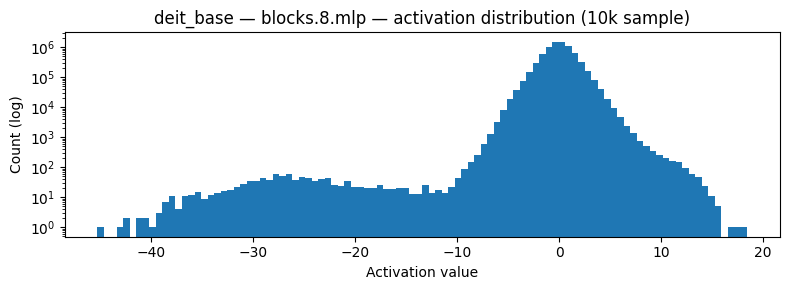

In [17]:
# ── Collect activations from target MLP layer ──────────────────────────────
cache_path = CACHE_DIR / f"acts_{TARGET_LAYER.replace('.', '_')}_{TOKEN_SELECTION}.pt" if CACHE_ACTS else None

activations, image_indices = collect_activations(
    model=model,
    dataloader=train_loader,
    target_layer=TARGET_LAYER,
    device=DEVICE,
    max_batches=MAX_BATCHES_COLLECT,
    cache_path=cache_path,
    token_selection=TOKEN_SELECTION,
    num_extra_tokens=MCFG["num_extra_tokens"],
)

print(f"\nActivations shape : {activations.shape}  (N_tokens × d_in)")
print(f"Image indices shape: {image_indices.shape}")
print(f"Memory usage       : {activations.nbytes / 1e9:.2f} GB")
print(f"Act mean           : {activations.mean():.4f}")
print(f"Act std            : {activations.std():.4f}")

# Quick distribution plot
sample = activations[torch.randperm(len(activations))[:10_000]].numpy()
plt.figure(figsize=(8, 3))
plt.hist(sample.flatten(), bins=100, log=True)
plt.xlabel("Activation value")
plt.ylabel("Count (log)")
plt.title(f"{MODEL_NAME} — {TARGET_LAYER} — activation distribution (10k sample)")
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "activation_distribution.png"), dpi=150)
plt.show()

In [18]:
# ── Build and train SAE ────────────────────────────────────────────────────
set_seed(SEED)

sae = TopKSAE(
    d_in=D_IN,
    d_sae=D_SAE,
    k=K_SPARSE,
)
print(f"SAE parameters: {sum(p.numel() for p in sae.parameters()):,}")
print(f"  W_enc: {tuple(sae.W_enc.shape)}")
print(f"  W_dec: {tuple(sae.W_dec.shape)}")

# Build a simple cfg namespace
sae_cfg = SimpleNamespace(
    training=SimpleNamespace(
        optimizer=SimpleNamespace(lr=LEARNING_RATE),
        batch_size=TRAIN_BATCH_SIZE,
        num_epochs=NUM_EPOCHS,
        scheduler=SimpleNamespace(warmup_steps=WARMUP_STEPS),
    )
)

history = train_sae(
    sae=sae,
    activations=activations,
    cfg=sae_cfg,
    device=DEVICE,
)

# Save checkpoint
sae_ckpt_path = SAVE_DIR / "sae_checkpoint.pth"
torch.save({
    "model_state_dict": sae.state_dict(),
    "d_in": D_IN, "d_sae": D_SAE, "k": K_SPARSE,
    "target_layer": TARGET_LAYER,
    "history": history,
}, sae_ckpt_path)
print(f"\nSAE checkpoint saved: {sae_ckpt_path}")

2026-05-08 18:46:02.296 | INFO     | src.xai.mechanistic.sae:train_sae:343 - b_pre ← dataset mean (from 10,000 samples)


SAE parameters: 6,296,320
  W_enc: (768, 4096)
  W_dec: (4096, 768)


/kaggle/working/xai-vit-medical/src/xai/mechanistic/sae.py:166: UserWarning: Using a target size (torch.Size([1, 768])) that is different to the input size (torch.Size([4096, 768])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  x_var = F.mse_loss(x, x.mean(0, keepdim=True)).item()
2026-05-08 18:52:29.342 | INFO     | src.xai.mechanistic.sae:train_sae:408 - SAE epoch 1/10 | recon=1.4967 | aux=0.0788 | L0=40.0/40 | R²=0.369
2026-05-08 18:58:57.008 | INFO     | src.xai.mechanistic.sae:train_sae:408 - SAE epoch 2/10 | recon=1.0271 | aux=0.0413 | L0=40.0/40 | R²=0.646
2026-05-08 19:05:18.350 | INFO     | src.xai.mechanistic.sae:train_sae:408 - SAE epoch 3/10 | recon=0.6331 | aux=0.0213 | L0=40.0/40 | R²=0.739
2026-05-08 19:11:36.584 | INFO     | src.xai.mechanistic.sae:train_sae:408 - SAE epoch 4/10 | recon=0.5083 | aux=0.0138 | L0=40.0/40 | R²=0.780
2026-05-08 19:17:54.992 | INFO     | src.xai.mechanistic.sae:train_sae:408 - SAE e


SAE checkpoint saved: /kaggle/working/xai-vit-medical/outputs/sae/deit_base/sae_checkpoint.pth


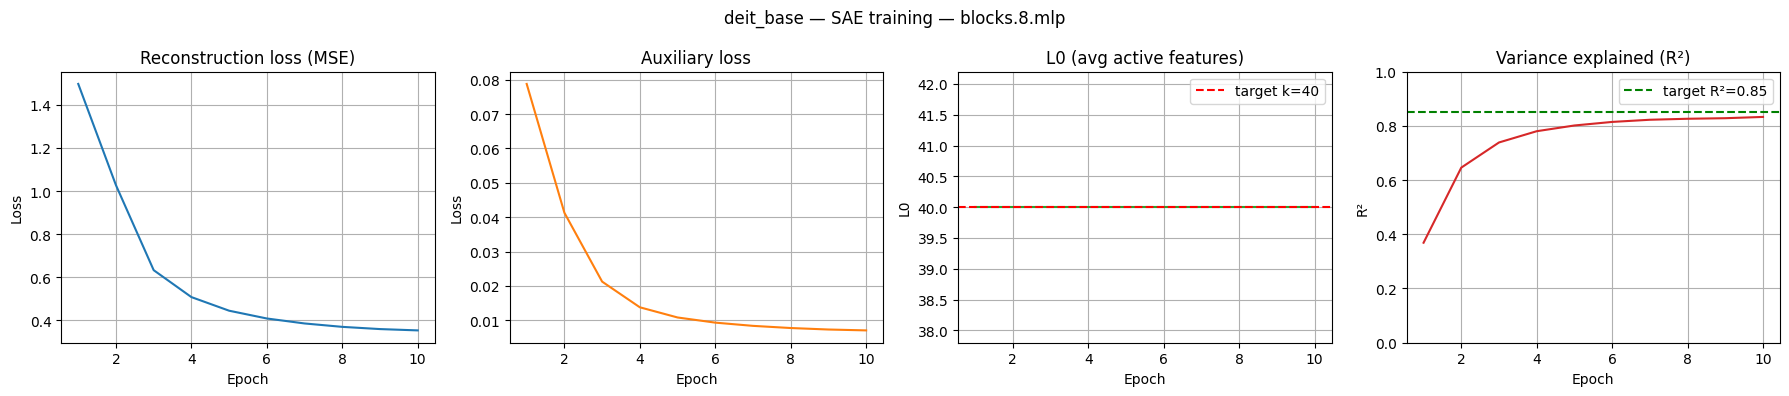


Final metrics:
  Reconstruction loss : 0.3539
  Auxiliary loss      : 0.0071
  L0                  : 40.0 / 40
  Variance explained  : 0.833


In [19]:
# ── Training curves ────────────────────────────────────────────────────────
epochs = range(1, len(history["reconstruction_loss"]) + 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f"{MODEL_NAME} — SAE training — {TARGET_LAYER}", fontsize=12)

axes[0].plot(epochs, history["reconstruction_loss"])
axes[0].set(title="Reconstruction loss (MSE)", xlabel="Epoch", ylabel="Loss")
axes[0].grid(True)

axes[1].plot(epochs, history["aux_loss"], color="tab:orange")
axes[1].set(title="Auxiliary loss", xlabel="Epoch", ylabel="Loss")
axes[1].grid(True)

axes[2].plot(epochs, history["L0"], color="tab:green")
axes[2].axhline(y=K_SPARSE, color="red", linestyle="--", label=f"target k={K_SPARSE}")
axes[2].legend()
axes[2].set(title="L0 (avg active features)", xlabel="Epoch", ylabel="L0")
axes[2].grid(True)

axes[3].plot(epochs, history["variance_explained"], color="tab:red")
axes[3].axhline(y=0.85, color="green", linestyle="--", label="target R²=0.85")
axes[3].legend()
axes[3].set(title="Variance explained (R²)", xlabel="Epoch", ylabel="R²")
axes[3].set_ylim(0, 1)
axes[3].grid(True)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / "training_curves.png"), dpi=150)
plt.show()

print(f"\nFinal metrics:")
print(f"  Reconstruction loss : {history['reconstruction_loss'][-1]:.4f}")
print(f"  Auxiliary loss      : {history['aux_loss'][-1]:.4f}")
print(f"  L0                  : {history['L0'][-1]:.1f} / {K_SPARSE}")
print(f"  Variance explained  : {history['variance_explained'][-1]:.3f}")

/tmp/ipykernel_57/3584935955.py:16: UserWarning: Using a target size (torch.Size([1, 768])) that is different to the input size (torch.Size([8192, 768])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  total_var = F.mse_loss(eval_acts, eval_acts.mean(0, keepdim=True)).item()


SAE quality on held-out 8192 tokens:
  Reconstruction MSE   : 0.35570
  Variance explained   : 0.833  (target >0.85)
  Mean L0              : 40.0  (target 40)
  Dead features        : 2240 / 4096  (54.7%)  (target <5%)


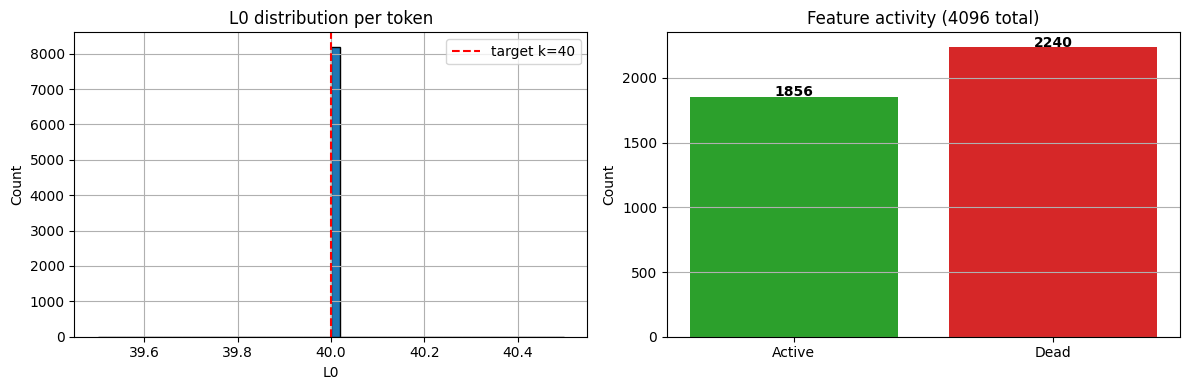

In [20]:
# ── SAE quality evaluation ─────────────────────────────────────────────────
sae.eval()

# Evaluate on a held-out 8192-token sample
n_eval = min(8192, len(activations))
eval_idx = torch.randperm(len(activations))[:n_eval]
eval_acts = activations[eval_idx].to(DEVICE)

with torch.no_grad():
    x_hat, codes, _ = sae(eval_acts)

# L0 distribution
L0_per_token = (codes > 0).float().sum(-1).cpu().numpy()
# Variance explained
recon_err = F.mse_loss(x_hat, eval_acts).item()
total_var = F.mse_loss(eval_acts, eval_acts.mean(0, keepdim=True)).item()
var_exp   = max(0, 1 - recon_err / (total_var + 1e-8))
# Dead features
feat_active = (codes > 0).float().sum(0).cpu()  # (d_sae,)
n_dead = (feat_active == 0).sum().item()
dead_ratio = n_dead / D_SAE

print("SAE quality on held-out 8192 tokens:")
print(f"  Reconstruction MSE   : {recon_err:.5f}")
print(f"  Variance explained   : {var_exp:.3f}  (target >0.85)")
print(f"  Mean L0              : {L0_per_token.mean():.1f}  (target {K_SPARSE})")
print(f"  Dead features        : {n_dead} / {D_SAE}  ({dead_ratio*100:.1f}%)  (target <5%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(L0_per_token, bins=50, edgecolor="black")
axes[0].axvline(x=K_SPARSE, color="red", linestyle="--", label=f"target k={K_SPARSE}")
axes[0].legend()
axes[0].set(title="L0 distribution per token", xlabel="L0", ylabel="Count")
axes[0].grid(True)

axes[1].bar(["Active", "Dead"], [D_SAE - n_dead, n_dead], color=["tab:green", "tab:red"])
axes[1].set(title=f"Feature activity ({D_SAE} total)", ylabel="Count")
for i, v in enumerate([D_SAE - n_dead, n_dead]):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.savefig(str(SAVE_DIR / "sae_quality.png"), dpi=150)
plt.show()

# Save metrics
with open(SAVE_DIR / "sae_metrics.json", "w") as f:
    json.dump({
        "model": MODEL_NAME,
        "target_layer": TARGET_LAYER,
        "d_sae": D_SAE, "k": K_SPARSE,
        "reconstruction_mse": recon_err,
        "variance_explained": var_exp,
        "mean_L0": float(L0_per_token.mean()),
        "n_dead_features": int(n_dead),
        "dead_feature_ratio": dead_ratio,
    }, f, indent=2)

In [21]:
# ── Collect activations from the test subset for feature analysis ──────────
# We need: activations (N_test, d_in), image_indices, labels, and original images
# We collect these in a single pass and keep raw images for visualization.

test_imgs_all: list[torch.Tensor] = []  # raw images for visualization
test_lbls_all: list[int] = []
test_ids_all: list[str]  = []

for batch in analysis_loader:
    if len(batch) == 3:
        imgs, lbls, ids = batch
    else:
        imgs, lbls = batch
        ids = [""] * len(lbls)
    test_imgs_all.append(imgs)
    test_lbls_all.extend(lbls.tolist())
    test_ids_all.extend(ids if isinstance(ids[0], str) else [str(x) for x in ids])

test_imgs_tensor = torch.cat(test_imgs_all, dim=0)  # (N_test, C, H, W)
test_labels = torch.tensor(test_lbls_all)
N_TEST = len(test_imgs_tensor)
print(f"Test images: {N_TEST}")

test_acts_cache = CACHE_DIR / f"test_acts_{TARGET_LAYER.replace('.','_')}_{TOKEN_SELECTION}.pt" if CACHE_ACTS else None

# Build a one-pass dataloader from the test subset images (no labels needed)
from torch.utils.data import TensorDataset
test_img_loader = DataLoader(
    TensorDataset(test_imgs_tensor),
    batch_size=STEER_BATCH_SIZE,
    shuffle=False,
)

# Monkey-patch: TensorDataset yields (tensor,) tuples, collect_activations expects (imgs, labels)
# We handle this by wrapping
class _PairWrapper:
    def __init__(self, loader):
        self._loader = loader
    def __iter__(self):
        for (imgs,) in self._loader:
            yield imgs, torch.zeros(len(imgs), dtype=torch.long)
    def __len__(self):
        return len(self._loader)

test_acts, test_img_idx = collect_activations(
    model=model,
    dataloader=_PairWrapper(test_img_loader),
    target_layer=TARGET_LAYER,
    device=DEVICE,
    max_batches=None,
    cache_path=test_acts_cache,
    token_selection=TOKEN_SELECTION,
    num_extra_tokens=MCFG["num_extra_tokens"],
)
print(f"Test activations: {test_acts.shape}  (image_indices range: {test_img_idx.min()}–{test_img_idx.max()})")

Test images: 270


2026-05-08 19:50:39.355 | DEBUG    | src.xai.mechanistic.sae:collect_activations:273 - collect_activations: batch 0 | 1,568 token vectors so far
2026-05-08 19:51:27.369 | DEBUG    | src.xai.mechanistic.sae:collect_activations:273 - collect_activations: batch 20 | 32,928 token vectors so far
2026-05-08 19:51:58.219 | INFO     | src.xai.mechanistic.sae:collect_activations:282 - Collected 52,920 activation vectors (270 images, d_in=768) from 'blocks.8.mlp'
2026-05-08 19:51:58.422 | INFO     | src.xai.mechanistic.sae:collect_activations:293 - Cached activations → /kaggle/working/xai-vit-medical/outputs/cache/deit_base/test_acts_blocks_8_mlp_patch.pt


Test activations: torch.Size([52920, 768])  (image_indices range: 0–269)


2026-05-08 19:51:58.443 | INFO     | src.xai.mechanistic.sae:analyze_features:468 - Analyzing 4096 SAE features over 52,920 activation vectors…
2026-05-08 19:51:58.677 | DEBUG    | src.xai.mechanistic.sae:analyze_features:494 -   feature analysis: 2,048/52,920 tokens processed
2026-05-08 19:52:03.915 | DEBUG    | src.xai.mechanistic.sae:analyze_features:494 -   feature analysis: 43,008/52,920 tokens processed
2026-05-08 19:52:05.296 | INFO     | src.xai.mechanistic.sae:analyze_features:512 - Feature analysis complete — 2444 / 4096 features are active (dead: 1652)



Feature statistics:
  Active features (freq>0)  : 2444 / 4096
  Mean activation frequency : 0.0098
  Max activation frequency  : 0.3959


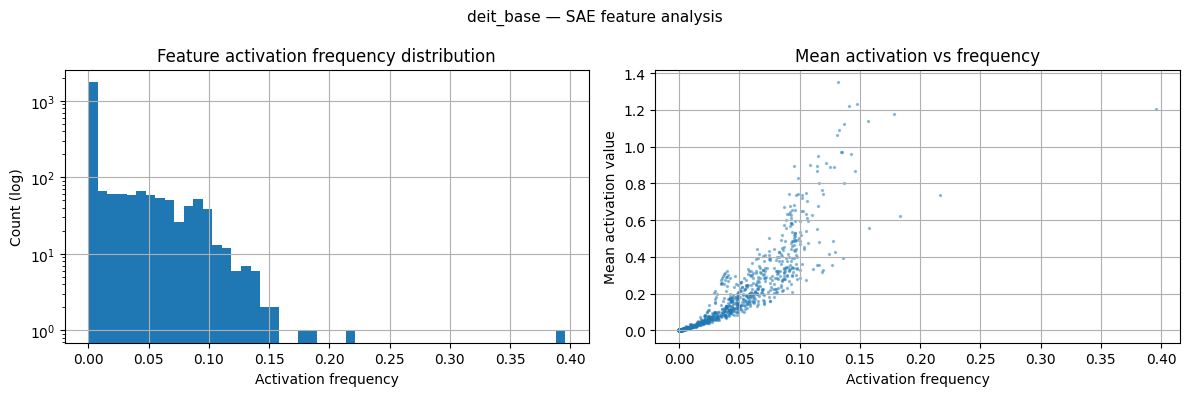


Features selected for visualization: [683, 520, 151, 3648, 4083, 770, 2629, 2027, 966, 2234]… (top by freq)


In [22]:
# ── Analyze SAE features — top-K activating images ─────────────────────────
# We analyse all D_SAE features but only visualize the top N_FEATURES_VISUALIZE
# by activation frequency (features that fire often are most interpretable).

feature_data = analyze_features(
    sae=sae,
    activations=test_acts,
    image_indices=test_img_idx,
    top_k_images=TOP_K_IMAGES_PER_FEATURE,
    batch_size=2048,
    device=DEVICE,
    num_features=D_SAE,
)

# Summary statistics
act_freqs = np.array([feature_data[i]["activation_frequency"] for i in range(D_SAE)])
mean_acts  = np.array([feature_data[i]["mean_activation"] for i in range(D_SAE)])

print(f"\nFeature statistics:")
print(f"  Active features (freq>0)  : {(act_freqs>0).sum()} / {D_SAE}")
print(f"  Mean activation frequency : {act_freqs.mean():.4f}")
print(f"  Max activation frequency  : {act_freqs.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(act_freqs[act_freqs > 0], bins=50, log=True)
axes[0].set(title="Feature activation frequency distribution",
            xlabel="Activation frequency", ylabel="Count (log)")
axes[0].grid(True)

axes[1].scatter(act_freqs, mean_acts, s=2, alpha=0.4)
axes[1].set(title="Mean activation vs frequency",
            xlabel="Activation frequency", ylabel="Mean activation value")
axes[1].grid(True)

plt.suptitle(f"{MODEL_NAME} — SAE feature analysis", fontsize=11)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "feature_statistics.png"), dpi=150)
plt.show()

# Select features to visualize: highest activation frequency (most "alive" features)
# Exclude ultra-common features (freq > 0.9) — these tend to be global, less specific
freq_mask = (act_freqs > 0) & (act_freqs < 0.9)
candidate_features = np.where(freq_mask)[0]
sorted_by_freq = candidate_features[np.argsort(act_freqs[candidate_features])[::-1]]
vis_features = sorted_by_freq[:N_FEATURES_VISUALIZE].tolist()
print(f"\nFeatures selected for visualization: {vis_features[:10]}… (top by freq)")

Saved 32 feature montages → /kaggle/working/xai-vit-medical/outputs/sae/deit_base/feature_montages


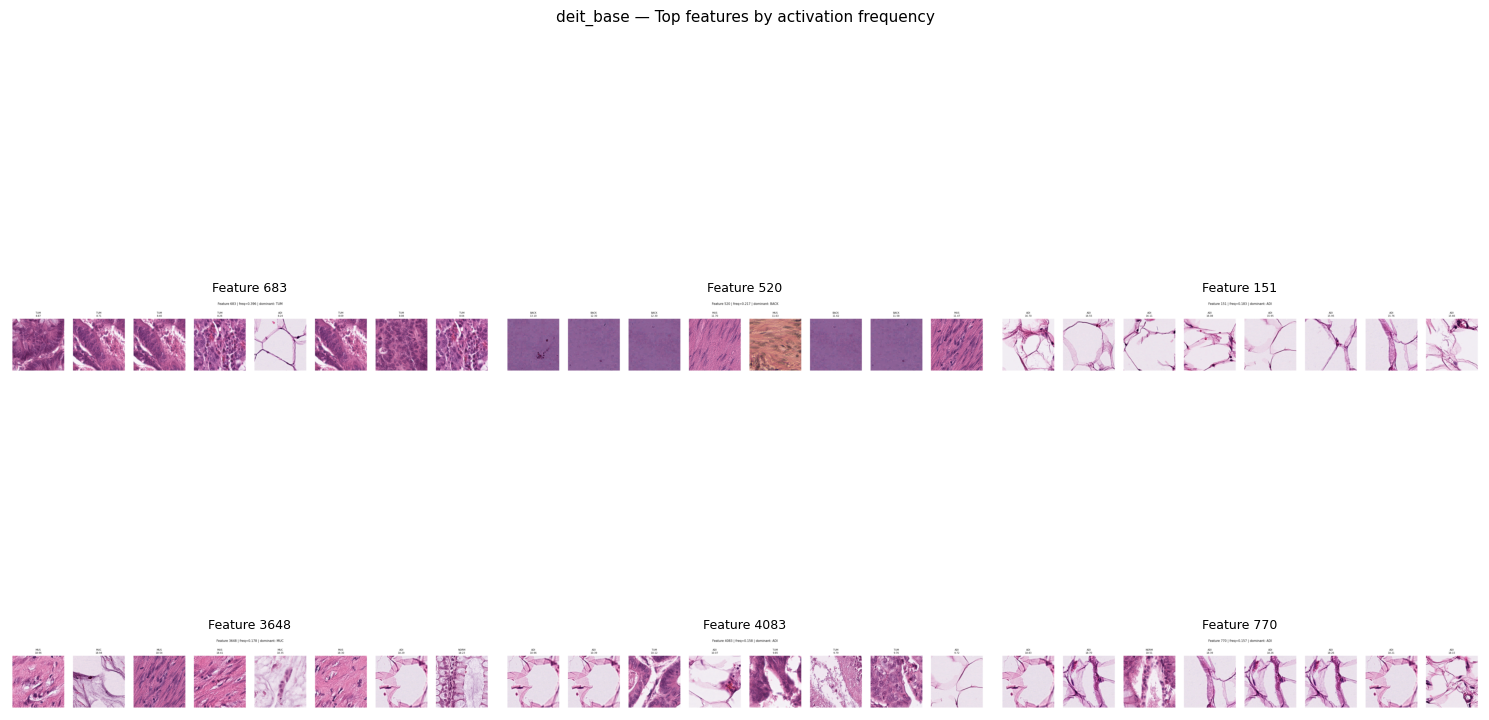

In [23]:
# ── Feature visualization — top-K activating image montage ─────────────────

def denormalize(img_chw: torch.Tensor) -> np.ndarray:
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img  = img_chw.detach().cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * std + mean, 0, 1)


def get_class_distribution(image_idx_list: list[int]) -> dict[str, int]:
    counts: dict[str, int] = defaultdict(int)
    for img_idx in image_idx_list:
        if img_idx < len(test_labels):
            lbl = int(test_labels[img_idx])
            counts[CLASS_NAMES[lbl]] += 1
    return dict(counts)


feat_viz_dir = SAVE_DIR / "feature_montages"
feat_viz_dir.mkdir(exist_ok=True)

N_COLS  = 8
N_SHOW  = min(TOP_K_IMAGES_PER_FEATURE, N_COLS)

for feat_idx in vis_features[:N_FEATURES_VISUALIZE]:
    fdata  = feature_data[feat_idx]
    img_idx_list = fdata["top_image_indices"].tolist()
    strengths    = fdata["activation_strengths"].tolist()
    freq         = fdata["activation_frequency"]
    class_dist   = get_class_distribution(img_idx_list)

    n_show = min(N_SHOW, len(img_idx_list))
    fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3.0))
    if n_show == 1:
        axes = [axes]

    dominant_class = max(class_dist, key=class_dist.get) if class_dist else "?"
    fig.suptitle(
        f"Feature {feat_idx} | freq={freq:.3f} | dominant: {dominant_class}",
        fontsize=9,
    )

    for col_i, (img_idx, strength) in enumerate(zip(img_idx_list[:n_show], strengths[:n_show])):
        ax = axes[col_i]
        if img_idx < len(test_imgs_tensor):
            ax.imshow(denormalize(test_imgs_tensor[img_idx]))
            lbl = int(test_labels[img_idx]) if img_idx < len(test_labels) else -1
            cn  = CLASS_NAMES[lbl] if 0 <= lbl < NUM_CLASSES else "?"
            ax.set_title(f"{cn[:6]}\n{strength:.2f}", fontsize=7)
        else:
            ax.set_visible(False)
        ax.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    out_path = feat_viz_dir / f"feat_{feat_idx:05d}.png"
    plt.savefig(str(out_path), dpi=120, bbox_inches="tight")
    plt.close()

print(f"Saved {N_FEATURES_VISUALIZE} feature montages → {feat_viz_dir}")

# Show first 6 in notebook
fig_all, axes_all = plt.subplots(2, 3, figsize=(15, 10))
for ax, feat_idx in zip(axes_all.flatten(), vis_features[:6]):
    img_path = feat_viz_dir / f"feat_{feat_idx:05d}.png"
    if img_path.exists():
        ax.imshow(Image.open(img_path))
    ax.set_title(f"Feature {feat_idx}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"{MODEL_NAME} — Top features by activation frequency", fontsize=11)
plt.tight_layout()
plt.show()

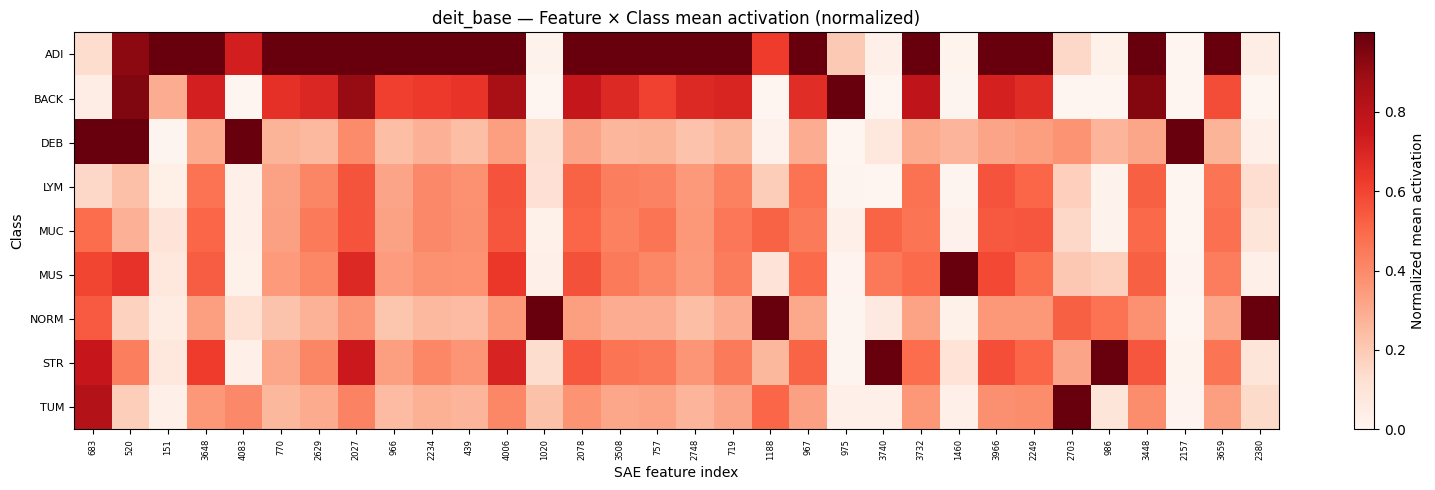


Most class-specific features (highest mean activation per class):
  ADI                 : feature 151  (mean act = 3.3360)
  BACK                : feature 975  (mean act = 3.3821)
  DEB                 : feature 2157  (mean act = 4.1771)
  LYM                 : feature 2748  (mean act = 1.1204)
  MUC                 : feature 2629  (mean act = 1.1811)
  MUS                 : feature 1460  (mean act = 2.5117)
  NORM                : feature 1020  (mean act = 2.1268)
  STR                 : feature 683  (mean act = 1.8243)
  TUM                 : feature 683  (mean act = 1.9722)


In [24]:
# ── Feature × Class heatmap ────────────────────────────────────────────────
# For each of the vis_features, compute the mean activation per class.
# This reveals class-specific features.

sae.eval()

# Encode test activations in one batch
with torch.no_grad():
    all_codes = []
    for start in range(0, len(test_acts), 2048):
        x = test_acts[start : start + 2048].to(DEVICE)
        all_codes.append(sae.encode(x).cpu())
    all_codes = torch.cat(all_codes, dim=0)  # (N_test_tokens, d_sae)

# Map each token to its image label
token_labels = test_labels[test_img_idx]  # (N_test_tokens,)

# Mean activation of selected features per class
n_vis = len(vis_features)
class_feat_matrix = np.zeros((NUM_CLASSES, n_vis))
for ci in range(NUM_CLASSES):
    class_mask = (token_labels == ci)
    if class_mask.sum() == 0:
        continue
    class_codes = all_codes[class_mask][:, vis_features]  # (n_class_tokens, n_vis)
    class_feat_matrix[ci] = class_codes.mean(0).numpy()

# Normalise columns for visibility
col_max = class_feat_matrix.max(0, keepdims=True) + 1e-8
class_feat_matrix_norm = class_feat_matrix / col_max

fig, ax = plt.subplots(figsize=(min(n_vis * 0.5, 20), 5))
im = ax.imshow(class_feat_matrix_norm, aspect="auto", cmap="Reds")
ax.set_yticks(range(NUM_CLASSES))
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xticks(range(n_vis))
ax.set_xticklabels([str(f) for f in vis_features], fontsize=6, rotation=90)
ax.set_xlabel("SAE feature index")
ax.set_ylabel("Class")
ax.set_title(f"{MODEL_NAME} — Feature × Class mean activation (normalized)")
plt.colorbar(im, ax=ax, label="Normalized mean activation")
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "feature_class_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

# Find the most class-specific features per class
print("\nMost class-specific features (highest mean activation per class):")
for ci, cname in enumerate(CLASS_NAMES):
    best_local  = np.argmax(class_feat_matrix[ci])  # index in vis_features
    best_global = vis_features[best_local]
    print(f"  {cname:20s}: feature {best_global}  (mean act = {class_feat_matrix[ci, best_local]:.4f})")

Features selected for ablation study: [2157, 975, 151, 1460, 2748]
  Feature  2157: Δprob = -0.0000 ± 0.0000
  Feature   975: Δprob = -0.0001 ± 0.0001
  Feature   151: Δprob = -0.0000 ± 0.0002
  Feature  1460: Δprob = +0.0000 ± 0.0000
  Feature  2748: Δprob = -0.0001 ± 0.0002


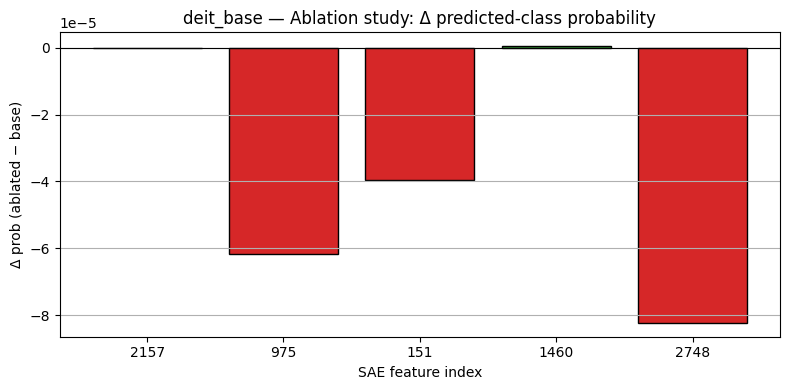

In [25]:
# ── Steerability: ablate SAE features, measure class-probability shift ──────
# For each of the top-5 features, we:
#   1. Run the model normally → get base class probability
#   2. Hook the target layer: SAE-encode the activation, zero the feature, re-decode
#   3. Run the modified forward → get ablated class probability
#   4. Report the mean change in predicted-class probability

from src.xai.mechanistic.sae import _get_module_by_path as _gmpath


def steered_forward(
    model: nn.Module,
    images: torch.Tensor,
    sae: TopKSAE,
    target_layer: str,
    feature_idx: int,
    mode: str = "ablate",
    strength: float = 0.0,
) -> torch.Tensor:
    """Forward pass with a single SAE feature ablated / amplified.

    Args:
        mode: ``"ablate"`` → set feature to 0;  ``"amplify"`` → multiply by strength.
    Returns:
        Logits ``(B, num_classes)``.
    """
    module = _gmpath(model, target_layer)

    def _hook(_mod, _inp, out: torch.Tensor) -> torch.Tensor:
        B, N_tok, D = out.shape
        flat = out.reshape(-1, D)                 # (B*N_tok, D)
        codes = sae.encode(flat)                   # (B*N_tok, d_sae)
        residual = flat - sae.decode(codes)         # un-captured residual
        if mode == "ablate":
            codes[:, feature_idx] = 0.0
        else:
            codes[:, feature_idx] *= strength
        patched = sae.decode(codes) + residual
        return patched.reshape(B, N_tok, D)

    handle = module.register_forward_hook(_hook)
    try:
        with torch.no_grad():
            out = model(images)
        if hasattr(out, "logits"):
            out = out.logits
        if isinstance(out, tuple):
            out = out[0]
    finally:
        handle.remove()
    return out


# Select top-5 features to ablate (highest class-specificity score)
# Class specificity = max activation across classes minus mean = sharpness
specificity = class_feat_matrix.max(0) - class_feat_matrix.mean(0)
specific_order = np.argsort(specificity)[::-1]
ablation_features = [vis_features[i] for i in specific_order[:5]]

print(f"Features selected for ablation study: {ablation_features}")

steer_results = []

steer_imgs = test_imgs_tensor[:N_STEER_IMAGES].to(DEVICE)
steer_lbls = test_labels[:N_STEER_IMAGES].tolist()

# Base predictions
with torch.no_grad():
    base_out = model(steer_imgs)
    if hasattr(base_out, "logits"):
        base_out = base_out.logits
    if isinstance(base_out, tuple):
        base_out = base_out[0]
base_probs = torch.softmax(base_out, dim=1).cpu()  # (N, num_classes)

for feat_idx in ablation_features:
    ablated_probs_list = []
    for start in range(0, N_STEER_IMAGES, STEER_BATCH_SIZE):
        batch_imgs = steer_imgs[start : start + STEER_BATCH_SIZE]
        ablated_logits = steered_forward(
            model=model,
            images=batch_imgs,
            sae=sae,
            target_layer=TARGET_LAYER,
            feature_idx=feat_idx,
            mode="ablate",
        )
        ablated_probs_list.append(torch.softmax(ablated_logits, dim=1).cpu())
    ablated_probs = torch.cat(ablated_probs_list, dim=0)  # (N, num_classes)

    # Change in predicted-class probability
    pred_class = base_probs.argmax(dim=1)
    base_pred_prob    = base_probs.gather(1, pred_class.unsqueeze(1)).squeeze(1)
    ablated_pred_prob = ablated_probs.gather(1, pred_class.unsqueeze(1)).squeeze(1)
    delta = (ablated_pred_prob - base_pred_prob).numpy()

    steer_results.append({
        "feature_idx"       : feat_idx,
        "mean_delta_prob"   : float(delta.mean()),
        "std_delta_prob"    : float(delta.std()),
        "mean_base_prob"    : float(base_pred_prob.mean()),
        "mean_ablated_prob" : float(ablated_pred_prob.mean()),
    })
    print(f"  Feature {feat_idx:5d}: Δprob = {delta.mean():+.4f} ± {delta.std():.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
feat_labels = [str(r["feature_idx"]) for r in steer_results]
deltas      = [r["mean_delta_prob"] for r in steer_results]
colors      = ["tab:red" if d < 0 else "tab:green" for d in deltas]
ax.bar(feat_labels, deltas, color=colors, edgecolor="black")
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title=f"{MODEL_NAME} — Ablation study: Δ predicted-class probability",
       xlabel="SAE feature index", ylabel="Δ prob (ablated − base)")
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "steerability_ablation.png"), dpi=150)
plt.show()

with open(SAVE_DIR / "steerability_results.json", "w") as f:
    json.dump(steer_results, f, indent=2)

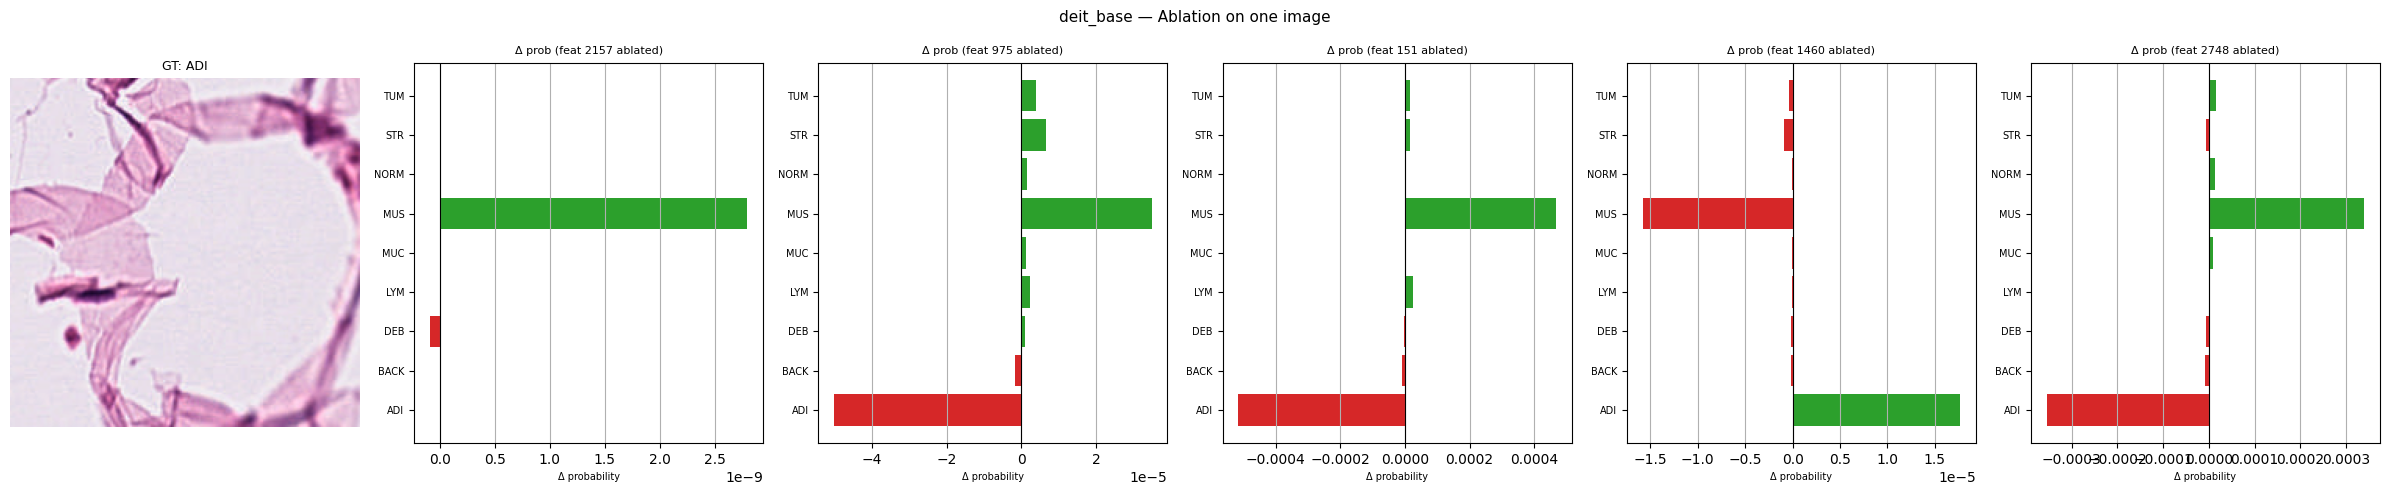

In [26]:
# ── Steerability visualization on a single image ───────────────────────────
# Show original vs ablated prediction probability change as a bar chart overlay.

sample_idx = 0  # first test image
sample_img = steer_imgs[sample_idx : sample_idx + 1]
sample_lbl = int(test_labels[sample_idx])

with torch.no_grad():
    base_logit  = model(sample_img)
    if hasattr(base_logit, "logits"):
        base_logit = base_logit.logits
    if isinstance(base_logit, tuple):
        base_logit = base_logit[0]
    base_prob_all = torch.softmax(base_logit, dim=1).cpu().squeeze().numpy()

n_feats_show = min(5, len(ablation_features))
fig, axes = plt.subplots(1, n_feats_show + 1, figsize=(4 * (n_feats_show + 1), 5))

# Original image
axes[0].imshow(denormalize(steer_imgs[sample_idx].cpu()))
axes[0].set_title(f"GT: {CLASS_NAMES[sample_lbl]}", fontsize=9)
axes[0].axis("off")

for col_i, feat_idx in enumerate(ablation_features[:n_feats_show], start=1):
    ablated_logit = steered_forward(
        model, sample_img, sae, TARGET_LAYER, feat_idx, mode="ablate"
    )
    ablated_prob_all = torch.softmax(ablated_logit, dim=1).cpu().squeeze().numpy()
    delta_all = ablated_prob_all - base_prob_all

    ax = axes[col_i]
    colors = ["tab:red" if d < 0 else "tab:green" for d in delta_all]
    ax.barh(range(NUM_CLASSES), delta_all, color=colors)
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels(CLASS_NAMES, fontsize=7)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Δ prob (feat {feat_idx} ablated)", fontsize=8)
    ax.set_xlabel("Δ probability", fontsize=7)
    ax.grid(True, axis="x")

plt.suptitle(f"{MODEL_NAME} — Ablation on one image", fontsize=11)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "ablation_single_image.png"), dpi=150)
plt.show()

Feature class-purity statistics (over 32 visualized features):
  Mean purity  : 0.695
  Median purity: 0.625
  >0.7 purity  : 10 features
  >0.9 purity  : 7 features


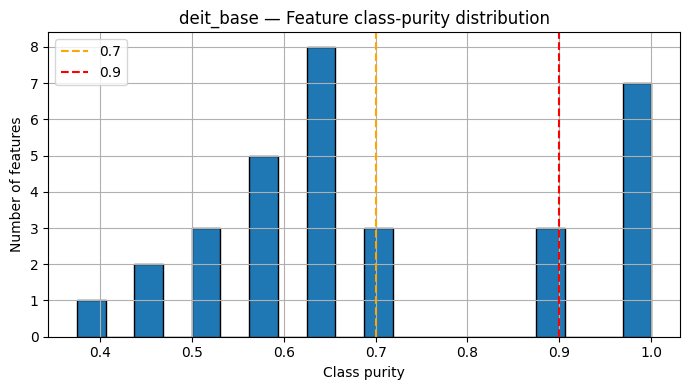


Saved feature summary: /kaggle/working/xai-vit-medical/outputs/sae/deit_base/feature_summary.json


In [27]:
# ── Save feature analysis summary ─────────────────────────────────────────
feature_summary = []
for feat_idx in vis_features:
    fdata = feature_data[feat_idx]
    img_idx_list = fdata["top_image_indices"].tolist()
    class_dist   = get_class_distribution(img_idx_list)
    dominant     = max(class_dist, key=class_dist.get) if class_dist else None
    purity       = class_dist.get(dominant, 0) / max(sum(class_dist.values()), 1) if dominant else 0.0
    feature_summary.append({
        "feature_idx"         : feat_idx,
        "activation_frequency": fdata["activation_frequency"],
        "mean_activation"     : fdata["mean_activation"],
        "dominant_class"      : dominant,
        "purity"              : purity,
        "class_distribution"  : class_dist,
    })

with open(SAVE_DIR / "feature_summary.json", "w") as f:
    json.dump(feature_summary, f, indent=2)

# Print class-purity distribution
purities = np.array([r["purity"] for r in feature_summary])
print(f"Feature class-purity statistics (over {len(vis_features)} visualized features):")
print(f"  Mean purity  : {purities.mean():.3f}")
print(f"  Median purity: {np.median(purities):.3f}")
print(f"  >0.7 purity  : {(purities > 0.7).sum()} features")
print(f"  >0.9 purity  : {(purities > 0.9).sum()} features")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(purities, bins=20, edgecolor="black")
ax.axvline(x=0.7, color="orange", linestyle="--", label="0.7")
ax.axvline(x=0.9, color="red",    linestyle="--", label="0.9")
ax.legend()
ax.set(title=f"{MODEL_NAME} — Feature class-purity distribution",
       xlabel="Class purity", ylabel="Number of features")
ax.grid(True)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "feature_purity.png"), dpi=150)
plt.show()

print(f"\nSaved feature summary: {SAVE_DIR / 'feature_summary.json'}")

In [34]:
SAVE_DIR

PosixPath('/kaggle/working/xai-vit-medical/outputs/sae/deit_base')

In [35]:
import json
# ── Upload results to Google Drive ─────────────────────────────────────────
RESULTS_DRIVE_FOLDER = DRIVE_FOLDER_ID  # same folder as checkpoint; update if needed

files_to_upload = [
    SAVE_DIR / "sae_checkpoint.pth",
    SAVE_DIR / "sae_metrics.json",
    SAVE_DIR / "training_curves.png",
    SAVE_DIR / "sae_quality.png",
    SAVE_DIR / "activation_distribution.png",
    SAVE_DIR / "feature_statistics.png",
    SAVE_DIR / "feature_class_heatmap.png",
    SAVE_DIR / "feature_purity.png",
    SAVE_DIR / "steerability_ablation.png",
    SAVE_DIR / "ablation_single_image.png",
    SAVE_DIR / "feature_summary.json",
    SAVE_DIR / "steerability_results.json",
]

# Also upload first N feature montages
montage_paths = sorted((SAVE_DIR / "feature_montages").glob("*.png"))[:20]
files_to_upload.extend(montage_paths)

for fpath in files_to_upload:
    fpath = Path(fpath)
    if not fpath.exists():
        print(f"  Not found (skipped): {fpath.name}")
        continue
    drive_file = drive.CreateFile({
        "title"  : f"{MODEL_NAME}_sae_{fpath.name}",
        "parents": [{"id": RESULTS_DRIVE_FOLDER}],
    })
    drive_file.SetContentFile(str(fpath))
    drive_file.Upload()
    print(f"  Uploaded: {MODEL_NAME}_sae_{fpath.name}")

print("\nDone.")

  Uploaded: deit_base_sae_sae_checkpoint.pth
  Uploaded: deit_base_sae_sae_metrics.json
  Uploaded: deit_base_sae_training_curves.png
  Uploaded: deit_base_sae_sae_quality.png
  Uploaded: deit_base_sae_activation_distribution.png
  Uploaded: deit_base_sae_feature_statistics.png
  Uploaded: deit_base_sae_feature_class_heatmap.png
  Uploaded: deit_base_sae_feature_purity.png
  Uploaded: deit_base_sae_steerability_ablation.png
  Uploaded: deit_base_sae_ablation_single_image.png
  Uploaded: deit_base_sae_feature_summary.json
  Uploaded: deit_base_sae_steerability_results.json
  Uploaded: deit_base_sae_feat_00151.png
  Uploaded: deit_base_sae_feat_00439.png
  Uploaded: deit_base_sae_feat_00520.png
  Uploaded: deit_base_sae_feat_00683.png
  Uploaded: deit_base_sae_feat_00719.png
  Uploaded: deit_base_sae_feat_00757.png
  Uploaded: deit_base_sae_feat_00770.png
  Uploaded: deit_base_sae_feat_00966.png
  Uploaded: deit_base_sae_feat_00967.png
  Uploaded: deit_base_sae_feat_00975.png
  Uploaded:

In [36]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Cleanup done.")

Cleanup done.
